# Recreate West Africa heatwave map (ERA5 daily Tmax mean)

This notebook recreates a single **West Africa** heat map similar to your benchmark figure, using **ERA5 post‑processed daily statistics** from the Copernicus Climate Data Store (CDS) and your **design-team color ramp**.

**Target window:** 31 March – 04 April 2024 (inclusive)

## What this notebook does
1. Downloads **daily maximum 2m air temperature** (Tmax) for the window and region via the CDS API.
2. Computes the **mean of daily Tmax** across the selected days.
3. Plots a publication-ready map with:
   - your custom color ramp (hotter = darker)
   - dashed country borders
   - horizontal colorbar
   - optional **isotherm contour(s)** to visually outline the hottest band ("Sahel boundary" proxy using temperature)
4. Saves the figure at publication resolution.

> **Prerequisite:** a CDS account + configured API key in `~/.cdsapirc`.

**Dataset used:** `derived-era5-single-levels-daily-statistics` (daily aggregation computed at retrieval time).


## 0) One-time setup (CDS API)

1. Create an account in the Copernicus Climate Data Store (CDS).
2. Create your API key.
3. Place a file at `~/.cdsapirc` with:

```
url: https://cds.climate.copernicus.eu/api
key: <UID>:<APIKEY>
```

If you already download ERA5 via CDS, you likely have this.


In [1]:
# If needed, install Python packages.
# NOTE: cartopy may require system libraries on some machines.
# If cartopy install fails, consider using conda-forge:
#   conda install -c conda-forge cartopy

import sys, subprocess, importlib

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

required = [
    "cdsapi",
    "xarray",
    "netcdf4",
    "numpy",
    "matplotlib",
    "cartopy",
]
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg if pkg != "netcdf4" else "netCDF4")
    except Exception:
        missing.append(pkg)

if missing:
    print("Installing:", missing)
    for pkg in missing:
        pip_install(pkg)
else:
    print("All required packages already installed.")


All required packages already installed.


In [ ]:
# Imports
import os
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import cartopy.crs as ccrs
import cartopy.feature as cfeature

## 1) User settings

Edit these parameters if needed.

- `AREA_NWSE` uses the CDS ordering **[North, West, South, East]**.
- Choose whether to plot:
  - `MAP_MODE = "tmax"` (default): mean of daily Tmax (°C)
  - `MAP_MODE = "anomaly"`: anomaly vs 1991–2020 mean for the same calendar days (heavier download)

> If you only need *one* map for the report, keep `MAP_MODE = "tmax"`.


In [13]:
# --- Date window (inclusive)
START_DATE = "2024-03-31"
END_DATE   = "2024-04-04"

# --- West Africa bounding box (North, West, South, East)
# Adjust as needed to match your report framing.
AREA_NWSE = [28.0, -20.0, 0.0, 20.0]

# --- Map mode: "tmax" or "anomaly"
MAP_MODE = "tmax"

# --- Climatology baseline (only used if MAP_MODE="anomaly")
CLIM_START_YEAR = 1991
CLIM_END_YEAR   = 2020  # inclusive

# --- Remove isotherms
ISOTHERM_LEVELS_C = []

# --- Color ramp (hotter = darker)
# Provided colors (dark -> light). For colormap we define low->high, so we reverse:
RAMP_DARK_TO_LIGHT = ["#903A74", "#A65D8E", "#BC80A9", "#D2A3C3", "#E8C6DD"]
RAMP_LOW_TO_HIGH = list(reversed(RAMP_DARK_TO_LIGHT))  # low (cool) -> high (hot)

# --- Temperature threshold styling (only used for MAP_MODE="tmax")
TEMP_BELOW_C = 40
TEMP_BELOW_COLOR = "#DADADA"

# --- Anomaly styling
ANOM_CLIP_PCTS = (2, 98)
ANOM_TICK_STEP = 1.0
ANOM_BELOW_C = 3.5  # Anomalies below this threshold appear in grey

# --- West Africa countries (grey out everything else)
WEST_AFRICA_COUNTRIES = [
    "Benin", "Burkina Faso", "Cape Verde", "Cabo Verde",
    "Gambia", "The Gambia", "Ghana", "Guinea", "Guinea-Bissau",
    "Ivory Coast", "Côte d'Ivoire", "Liberia", "Mali",
    "Mauritania", "Niger", "Nigeria", "Senegal",
    "Sierra Leone", "Togo"
]

# --- Clipping for color scaling (robust to outliers)
# Use percentiles for a stable look; adjust to (0, 100) to use full min/max.
CLIP_PCTS = (2, 98)

# --- Repository paths
# Assumes notebook is in notebooks/Storylines/ folder
REPO_ROOT = Path.cwd().parent.parent if Path.cwd().name == "Storylines" else Path.cwd()
if not (REPO_ROOT / "data").exists():
    # Fallback: try to find repo root by looking for data folder
    current = Path.cwd()
    while current != current.parent:
        if (current / "data").exists():
            REPO_ROOT = current
            break
        current = current.parent

RAW_DATA_DIR = REPO_ROOT / "data" / "raw" / "Storylines" / "WestAfricaHeat"
OUTPUT_DIR = REPO_ROOT / "data" / "output" / "storylines"
CDSAPI_RC_PATH = REPO_ROOT / ".cdsapirc"

# --- Output settings
DPI = 600  # publication resolution
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
output_prefix = "tmax_anomaly" if MAP_MODE.lower() == "anomaly" else "tmax_mean"
OUTFILE = OUTPUT_DIR / f"west_africa_{output_prefix}_{START_DATE.replace('-','')}_{END_DATE.replace('-','')}.png"

## 2) Helper functions

In [14]:

import datetime as dt
import os
import cdsapi

def daterange(start_date: str, end_date: str):
    start = dt.date.fromisoformat(start_date)
    end = dt.date.fromisoformat(end_date)
    if end < start:
        raise ValueError("END_DATE must be >= START_DATE")
    cur = start
    while cur <= end:
        yield cur
        cur += dt.timedelta(days=1)

def ensure_cdsapirc(explicit_path=None):
    # Basic check that cdsapi credentials exist; sets CDSAPI_RC if found.
    candidates = []
    if explicit_path:
        candidates.append(Path(explicit_path))
    env_path = os.environ.get("CDSAPI_RC")
    if env_path:
        candidates.append(Path(env_path))

    # Standard location
    candidates.append(Path.home() / ".cdsapirc")

    # Look in current working directory and its parents
    cwd = Path.cwd()
    candidates.append(cwd / ".cdsapirc")
    candidates.extend(parent / ".cdsapirc" for parent in cwd.parents)

    # De-dupe while preserving order
    seen = set()
    unique_candidates = []
    for p in candidates:
        try:
            rp = p.expanduser().resolve()
        except Exception:
            rp = p
        key = str(rp)
        if key in seen:
            continue
        seen.add(key)
        unique_candidates.append(p)

    for cfg in unique_candidates:
        try:
            if cfg.expanduser().exists():
                os.environ["CDSAPI_RC"] = str(cfg.expanduser())
                return cfg.expanduser()
        except Exception:
            continue

    searched = "\n".join(f"- {p}" for p in unique_candidates)
    raise FileNotFoundError(
        "Missing CDS API config file (.cdsapirc). Searched:\n"
        f"{searched}\n"
        "Set CDSAPI_RC_PATH in the settings cell or define the CDSAPI_RC env var."
    )

def cds_retrieve_daily_tmax(year: int, months: list, days: list, target_path: Path, area_nwse=None):
    '''
    Retrieve daily maximum 2m temperature (computed from hourly 2m_temperature) for specified dates.
    Dataset: derived-era5-single-levels-daily-statistics
    '''
    client = cdsapi.Client()
    request = {
        "product_type": "reanalysis",
        "variable": ["2m_temperature"],
        "year": [str(year)],
        "month": [f"{m:02d}" for m in months],
        "day": [f"{d:02d}" for d in days],
        "daily_statistic": "daily_maximum",
        "time_zone": "utc+00:00",
        "frequency": "1_hourly",
        "format": "netcdf",
    }
    if area_nwse is not None:
        request["area"] = [float(x) for x in area_nwse]  # [N, W, S, E]
    # CDS returns netcdf for this request; keep zip handling downstream just in case.
    client.retrieve("derived-era5-single-levels-daily-statistics", request, str(target_path))
    return target_path

def open_retrieved_netcdf(zip_or_nc_path: Path) -> xr.Dataset:
    '''
    CDS commonly returns a .nc; some endpoints return a .zip with .nc inside.
    This opens the first .nc inside if needed.
    '''
    path = Path(zip_or_nc_path)
    if path.suffix.lower() == ".nc":
        return xr.open_dataset(path)
    if path.suffix.lower() == ".zip":
        import zipfile, tempfile
        with zipfile.ZipFile(path, "r") as zf:
            nc_files = [n for n in zf.namelist() if n.lower().endswith(".nc")]
            if not nc_files:
                raise RuntimeError(f"No .nc files found inside {path}")
            tmpdir = tempfile.mkdtemp()
            zf.extract(nc_files[0], path=tmpdir)
            nc_path = Path(tmpdir) / nc_files[0]
            return xr.open_dataset(nc_path)
    raise ValueError(f"Unsupported file type: {path}")

## 3) Download daily Tmax and compute the mean (31 Mar – 04 Apr 2024)

In [15]:

ensure_cdsapirc(CDSAPI_RC_PATH)

# Determine months/days involved (simple for this short window)
dates = list(daterange(START_DATE, END_DATE))
year = dates[0].year
if any(d.year != year for d in dates):
    raise ValueError("This notebook expects the window to be within a single year. Split requests otherwise.")

months = sorted(set(d.month for d in dates))
days_by_month = {m: sorted(set(d.day for d in dates if d.month == m)) for m in months}

raw_dir = RAW_DATA_DIR
raw_dir.mkdir(exist_ok=True, parents=True)

# Retrieve per-month (small requests)
nc_paths = []
for m in months:
    out_nc = raw_dir / f"era5_daily_tmax_{year}{m:02d}_{START_DATE}_{END_DATE}.nc"
    if not out_nc.exists():
        print(f"Downloading ERA5 daily Tmax for {year}-{m:02d}, days={days_by_month[m]} ...")
        cds_retrieve_daily_tmax(year, [m], days_by_month[m], out_nc, area_nwse=AREA_NWSE)
    else:
        print(f"Found cached: {out_nc}")
    nc_paths.append(out_nc)

# Open and concatenate
datasets = [open_retrieved_netcdf(p) for p in nc_paths]
ds = xr.concat(datasets, dim="time")

# Detect the temperature variable robustly
var_candidates = [v for v in ds.data_vars if "temperature" in v.lower() or v.lower() in ("t2m",)]
if not var_candidates:
    raise KeyError(f"Could not find a temperature variable in {list(ds.data_vars)}")
temp_var = var_candidates[0]
print("Using temperature variable:", temp_var)

tmax_k = ds[temp_var]

# Pick a time coordinate name
if "time" in tmax_k.coords:
    time_name = "time"
elif "valid_time" in tmax_k.coords:
    time_name = "valid_time"
elif "time" in tmax_k.dims:
    time_name = "time"
else:
    time_name = next((c for c in tmax_k.coords if "time" in c.lower()), None)
    if time_name is None:
        raise KeyError("No time coordinate found for selecting the date window.")

# Ensure time is datetime-like (decode if needed)
if time_name in tmax_k.coords and not np.issubdtype(tmax_k[time_name].dtype, np.datetime64):
    tmax_k = xr.decode_cf(tmax_k.to_dataset(name="tmax")).tmax

# Subset exact time window (safe)
if time_name in tmax_k.coords or time_name in tmax_k.dims:
    tmax_k = tmax_k.sel({time_name: slice(np.datetime64(START_DATE), np.datetime64(END_DATE))})

# Convert to Celsius
tmax_c = tmax_k - 273.15
tmax_c.attrs["units"] = "°C"

# Reduce any non-spatial dims (e.g., time/number) to a mean
lon_name = "longitude" if "longitude" in tmax_c.coords else "lon"
lat_name = "latitude" if "latitude" in tmax_c.coords else "lat"
spatial_dims = [d for d in (lat_name, lon_name) if d in tmax_c.dims]
reduce_dims = [d for d in tmax_c.dims if d not in spatial_dims]
tmax_mean_c = tmax_c.mean(reduce_dims, keep_attrs=True) if reduce_dims else tmax_c
tmax_mean_c.name = "tmax_mean"

print(tmax_mean_c)


Found cached: c:\pipelines\sewa-multihazar\data\raw\Storylines\WestAfricaHeat\era5_daily_tmax_202403_2024-03-31_2024-04-04.nc
Found cached: c:\pipelines\sewa-multihazar\data\raw\Storylines\WestAfricaHeat\era5_daily_tmax_202404_2024-03-31_2024-04-04.nc
Using temperature variable: t2m
<xarray.DataArray 'tmax_mean' (latitude: 113, longitude: 161)> Size: 73kB
array([[20.924078, 20.88355 , 20.844732, ..., 31.89864 , 32.08184 ,
        32.34356 ],
       [20.947956, 20.900105, 20.83697 , ..., 31.769342, 31.854107,
        32.043953],
       [20.975153, 20.870464, 20.787556, ..., 31.703327, 31.774323,
        31.851665],
       ...,
       [28.586578, 28.537994, 28.458502, ..., 32.728374, 32.694782,
        32.562603],
       [28.419683, 28.342682, 28.269146, ..., 32.7065  , 32.748493,
        32.905964],
       [28.282965, 28.261774, 28.193317, ..., 33.016754, 32.994194,
        33.23824 ]], dtype=float32)
Coordinates:
  * latitude   (latitude) float64 904B 28.0 27.75 27.5 27.25 ... 0.5 0.25

## 4) Optional: compute an anomaly (vs 1991–2020)

In [16]:

# Optional and heavier: downloads multiple years.
# If you only need the mean Tmax map, keep MAP_MODE='tmax' and skip.

anom_mean_c = None

if MAP_MODE.lower() == "anomaly":
    print("Computing anomaly vs climatology (this can take a while)...")

    dates = list(daterange(START_DATE, END_DATE))
    target_months = sorted(set(d.month for d in dates))
    target_days = sorted(set(d.day for d in dates))

    clim_dir = RAW_DATA_DIR / "climatology"
    clim_dir.mkdir(exist_ok=True, parents=True)

    clim_years = list(range(CLIM_START_YEAR, CLIM_END_YEAR + 1))

    clim_means = []
    for y in clim_years:
        out_nc = clim_dir / f"era5_daily_tmax_clim_{y}_{START_DATE}_{END_DATE}.nc"
        if not out_nc.exists():
            client = cdsapi.Client()
            req = {
                "product_type": "reanalysis",
                "variable": ["2m_temperature"],
                "year": [str(y)],
                "month": [f"{m:02d}" for m in target_months],
                "day": [f"{d:02d}" for d in target_days],
                "daily_statistic": "daily_max",
                "time_zone": "utc+00:00",
                "frequency": "1_hourly",
                "format": "netcdf",
                "area": [float(x) for x in AREA_NWSE],
            }
            client.retrieve("derived-era5-single-levels-daily-statistics", req, str(out_nc))

        ds_y = open_retrieved_netcdf(out_nc)
        var_candidates_y = [v for v in ds_y.data_vars if "temperature" in v.lower() or v.lower() in ("t2m",)]
        tv = var_candidates_y[0]
        t_y = ds_y[tv] - 273.15

        if "time" in t_y.coords:
            time_name_y = "time"
        elif "valid_time" in t_y.coords:
            time_name_y = "valid_time"
        elif "time" in t_y.dims:
            time_name_y = "time"
        else:
            time_name_y = next((c for c in t_y.coords if "time" in c.lower()), None)
            if time_name_y is None:
                raise KeyError("No time coordinate found in climatology data.")

        if time_name_y in t_y.coords and not np.issubdtype(t_y[time_name_y].dtype, np.datetime64):
            t_y = xr.decode_cf(t_y.to_dataset(name="tmax")).tmax

        if time_name_y in t_y.coords or time_name_y in t_y.dims:
            t_y = t_y.sel({time_name_y: slice(np.datetime64(f"{y}-03-31"), np.datetime64(f"{y}-04-04"))})

        lon_name_y = "longitude" if "longitude" in t_y.coords else "lon"
        lat_name_y = "latitude" if "latitude" in t_y.coords else "lat"
        spatial_dims_y = [d for d in (lat_name_y, lon_name_y) if d in t_y.dims]
        reduce_dims_y = [d for d in t_y.dims if d not in spatial_dims_y]
        clim_means.append(t_y.mean(reduce_dims_y))

    clim_mean = xr.concat(clim_means, dim="year").mean("year")
    anom_mean_c = tmax_mean_c - clim_mean
    anom_mean_c.name = "tmax_anomaly"
    anom_mean_c.attrs["units"] = "°C"
    print("Anomaly computed.")
else:
    print("MAP_MODE is not 'anomaly' — skipping anomaly computation.")


MAP_MODE is not 'anomaly' — skipping anomaly computation.


## 5) Plot the map (custom ramp + dashed borders + optional isotherms)

C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_34472\2226014458.py:34: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  land_mask = shpvec.contains(land_union, lon2d, lat2d)
C:\Users\duruenaramirez\AppData\Local\Temp\ipykernel_34472\2226014458.py:62: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  wa_mask = shpvec.contains(wa_union, lon2d, lat2d)


Color scaling (clipped): vmin=40.00, vmax=44.58
Saved: C:\pipelines\sewa-multihazar\data\output\storylines\west_africa_tmax_mean_20240331_20240404.png


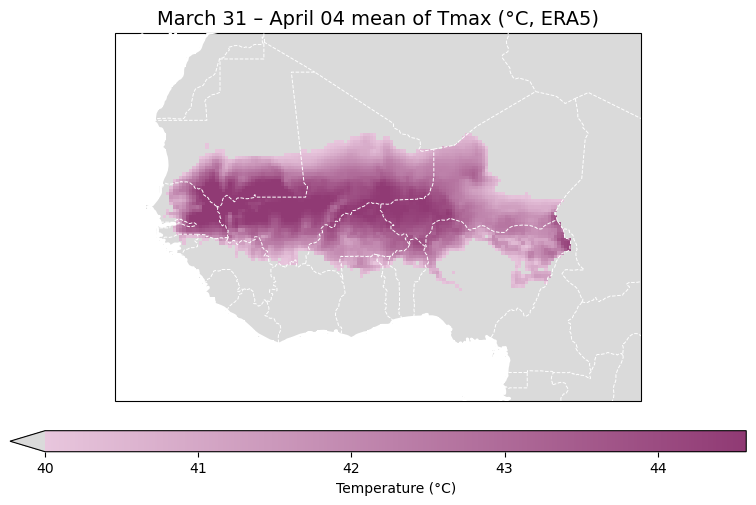

In [17]:
# Select which field to plot
if MAP_MODE.lower() == "anomaly":
    if anom_mean_c is None:
        raise RuntimeError("MAP_MODE='anomaly' but anomaly is not computed. Run the anomaly cell first.")
    field = anom_mean_c
    title = "March 31 – April 04 mean Tmax anomaly (°C, vs 1991–2020)"
else:
    field = tmax_mean_c
    title = "March 31 – April 04 mean of Tmax (°C, ERA5)"

# Coords
lon_name = "longitude" if "longitude" in field.coords else "lon"
lat_name = "latitude" if "latitude" in field.coords else "lat"

# Build land mask from Natural Earth polygons (ocean -> white)
import cartopy.io.shapereader as shpreader
from shapely.ops import unary_union
from shapely.prepared import prep
from shapely.geometry import Point
try:
    from shapely import vectorized as shpvec
    _has_vec = True
except Exception:
    _has_vec = False

land_shp = shpreader.natural_earth(resolution="50m", category="physical", name="land")
land_geoms = [rec.geometry for rec in shpreader.Reader(land_shp).records()]
land_union = unary_union(land_geoms)

lon = field[lon_name].values
lat = field[lat_name].values
lon2d, lat2d = np.meshgrid(lon, lat)
if _has_vec:
    land_mask = shpvec.contains(land_union, lon2d, lat2d)
else:
    land_prep = prep(land_union)
    land_mask = np.zeros(lon2d.shape, dtype=bool)
    for i in range(lon2d.shape[0]):
        for j in range(lon2d.shape[1]):
            land_mask[i, j] = land_prep.contains(Point(lon2d[i, j], lat2d[i, j]))
land_mask_da = xr.DataArray(land_mask, coords={lat_name: lat, lon_name: lon}, dims=(lat_name, lon_name))

# Build West Africa country mask
countries_shp = shpreader.natural_earth(resolution="50m", category="cultural", name="admin_0_countries")
wa_geoms = []
for country in shpreader.Reader(countries_shp).records():
    name = country.attributes.get('NAME', '')
    name_long = country.attributes.get('NAME_LONG', '')
    admin = country.attributes.get('ADMIN', '')
    # Match against multiple possible name fields
    if any(wa_name in [name, name_long, admin] for wa_name in WEST_AFRICA_COUNTRIES):
        wa_geoms.append(country.geometry)

if not wa_geoms:
    print("Warning: No West Africa countries found. Available names:")
    for country in shpreader.Reader(countries_shp).records():
        print(f"  {country.attributes.get('NAME')}")
    raise ValueError("Could not find West Africa countries in Natural Earth dataset.")

wa_union = unary_union(wa_geoms)
if _has_vec:
    wa_mask = shpvec.contains(wa_union, lon2d, lat2d)
else:
    wa_prep = prep(wa_union)
    wa_mask = np.zeros(lon2d.shape, dtype=bool)
    for i in range(lon2d.shape[0]):
        for j in range(lon2d.shape[1]):
            wa_mask[i, j] = wa_prep.contains(Point(lon2d[i, j], lat2d[i, j]))
wa_mask_da = xr.DataArray(wa_mask, coords={lat_name: lat, lon_name: lon}, dims=(lat_name, lon_name))

# Build plot field and scale
# Both modes use the same custom purple gradient (design requirement)
cmap = LinearSegmentedColormap.from_list("custom_ramp", RAMP_LOW_TO_HIGH, N=256)
cmap.set_bad("white")
norm = None

if MAP_MODE.lower() == "anomaly":
    vals = field.values
    vmin = float(np.nanpercentile(vals, ANOM_CLIP_PCTS[0]))
    vmax = float(np.nanpercentile(vals, ANOM_CLIP_PCTS[1]))
    vmin = max(vmin, float(ANOM_BELOW_C))
    # Mask ocean to NaN (white), non-WA land to 0 (grey), keep WA data
    field_land = field.where(land_mask_da)  # Ocean -> NaN
    field_wa = field_land.where(wa_mask_da)  # Non-WA land -> NaN
    # Below threshold in WA -> 0 (grey), ocean/non-WA stay NaN unless non-WA land
    field_plot = xr.where(
        land_mask_da & ~wa_mask_da, 0.0,  # Non-WA land -> grey
        xr.where((field_wa >= ANOM_BELOW_C) | field_wa.isnull(), field_wa, 0.0)  # WA: below threshold -> grey
    )
    cmap.set_under(TEMP_BELOW_COLOR)
    cbar_label = "Temperature anomaly (°C)"
    cbar_extend = "min"
    cbar_ticks = None
else:
    vals = field.values
    vmin = float(np.nanpercentile(vals, CLIP_PCTS[0]))
    vmax = float(np.nanpercentile(vals, CLIP_PCTS[1]))
    vmin = max(vmin, float(TEMP_BELOW_C))
    # Mask ocean to NaN (white), non-WA land to 0 (grey), keep WA data
    field_land = field.where(land_mask_da)  # Ocean -> NaN
    field_wa = field_land.where(wa_mask_da)  # Non-WA land -> NaN
    # Below threshold in WA -> 0 (grey), ocean/non-WA stay NaN unless non-WA land
    field_plot = xr.where(
        land_mask_da & ~wa_mask_da, 0.0,  # Non-WA land -> grey
        xr.where((field_wa >= TEMP_BELOW_C) | field_wa.isnull(), field_wa, 0.0)  # WA: below threshold -> grey
    )
    cmap.set_under(TEMP_BELOW_COLOR)
    cbar_label = "Temperature (°C)"
    cbar_extend = "min"
    cbar_ticks = None

print(f"Color scaling (clipped): vmin={vmin:.2f}, vmax={vmax:.2f}")

# Plot
plt.figure(figsize=(9.5, 5.5), facecolor="white")
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor("white")
ax.set_extent([AREA_NWSE[1], AREA_NWSE[3], AREA_NWSE[2], AREA_NWSE[0]], crs=ccrs.PlateCarree())

mesh = ax.pcolormesh(
    field_plot[lon_name],
    field_plot[lat_name],
    field_plot,
    cmap=cmap,
    shading="auto",
    transform=ccrs.PlateCarree(),
    vmin=None if norm else vmin,
    vmax=None if norm else vmax,
    norm=norm,
    zorder=2,
)

# Add features on top (white borders and coastline)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.7, linestyle="--", edgecolor="white", zorder=3)
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=2.0, edgecolor="white", zorder=3)

ax.set_title(title, fontsize=14)

# Horizontal colorbar
cbar = plt.colorbar(
    mesh,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    fraction=0.06,
    aspect=35,
    extend=cbar_extend,
    ticks=cbar_ticks,
)
cbar.set_label(cbar_label)

# Save
plt.savefig(OUTFILE, dpi=DPI, bbox_inches="tight", facecolor="white")
print("Saved:", OUTFILE.resolve())

plt.show()

## 6) Notes for the report

- ERA5 temperatures are returned in **Kelvin**; this notebook converts to **°C**.
- The daily Tmax statistic is computed during retrieval (not permanently archived).
- For consistent styling across events, consider fixing `CLIP_PCTS` or fixing `vmin/vmax` once you are happy with the look.

### Data acknowledgement
The CDS catalogue page for this dataset provides the DOI and licence (CC‑BY). Use that DOI in your references section if needed.
